# Lab 3 — Character-level GPT on Kazakh Poetry
**Corpus:** Мағжан Жұмабаев, Шығармалары 1-том (Өлеңдер мен дастандар)

## 0. Upload corpus

In [1]:
from google.colab import files
uploaded = files.upload()

Saving poems.txt to poems.txt


## 1. Load and inspect corpus

In [2]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Change filename if yours is different
CORPUS_FILE = list(uploaded.keys())[0]

with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Total characters: {len(text):,}')
print(f'Total lines: {len(text.splitlines()):,}')
print(f'Total size: {len(text.encode("utf-8")) / 1024:.1f} KB')
print()
print('--- First 500 chars ---')
print(text[:500])

Total characters: 571,006
Total lines: 25,263
Total size: 993.7 KB

--- First 500 chars ---
﻿Өлең - сөздің патшасы, сөз сарасы


Өлең - сөздің патшасы, сөз сарасы,
Қиыннан қиыстырар ер данасы.
Тілге жеңіл, жүрекке жылы тиіп,
Теп-тегіс жұмыр келсін айналасы. 
Бөтен сөзбен былғанса сөз арасы,
Ол - ақынның білімсіз бишарасы.
Айтушы мен тыңдаушы көбі надан,
Бұл жұрттың сөз танымас бір парасы.
Әуелі хаят, хәдис - сөздің басы,
Қосарлы бәйітмысал келді арасы.
Қисынымен қызықты болмаса сөз,
Неге айтсын пайғамбар мен оны алласы.
Мешіттің құтпа оқыған ғұламасы,
Мүнәжәт уәлилердің зар наласы.
Бір


## 2. Tokenisation (character-level)

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join([itos[i] for i in ids])

data = torch.tensor(encode(text), dtype=torch.long)

print(f'Vocabulary size: {vocab_size}')
print(f'Characters: {repr("".join(chars))}')
print()
print('Roundtrip check:', decode(encode(text[:100])) == text[:100])

Vocabulary size: 142
Characters: '\n !"()*,-./0123456789:;?ABDEGHILNOPQRVXabdefghilmsty~«\xad¹»ІАБВГДЕЖЗИЙКЛМНОПРСТУФХЦШЫЬЭЮЯабвгдежзийклмнопрстуфхцчшщъыьэюяіћҒғҚқҢңҮүҰұҺһӘәӨө–—“”\ufeff'

Roundtrip check: True


## 3. Train / val split

In [5]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print(f'Train tokens: {len(train_data):,}  |  Val tokens: {len(val_data):,}')

Device: cuda
Train tokens: 513,905  |  Val tokens: 57,101


## 4. Hyperparameters (baseline)

In [6]:
# Baseline configuration
block_size    = 256   # context length — covers ~3-4 stanzas of Kazakh verse
batch_size    = 32
n_embd        = 128
n_head        = 4
n_layer       = 4
dropout       = 0.1
learning_rate = 3e-4

# Positional embedding choice: LEARNED
# Sinusoidal embeddings generalise to unseen lengths but are fixed.
# RoPE requires modifying attention scores — adds complexity.
# For a fixed context length (256) and a small corpus, learned embeddings
# are simpler and perform comparably. This is the standard choice for GPT-style models.
print('Baseline config ready.')

Baseline config ready.


## 5. Data loader

In [7]:
def get_batch(split):
    source = train_data if split == 'train' else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size]     for i in ix])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

## 6. Loss estimator

In [8]:
@torch.no_grad()
def estimate_loss(eval_iters=200):
    """Average loss over eval_iters random batches, with dropout disabled."""
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 7. Model architecture

Parameters are passed explicitly to the constructor to avoid hidden global-state bugs when running hyperparameter experiments.

In [9]:
# ── FlashAttention head (uses torch SDPA) ─────────────────────────────────
class HeadFlash(nn.Module):
    def __init__(self, head_size, n_embd, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        # is_causal=True applies the causal mask automatically
        # On a CUDA GPU this dispatches FlashAttention when available
        return F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                              dropout_p=self.drop.p if self.training else 0.0)


# ── Manual masked attention head (classic triangular-mask approach) ────────
class HeadManual(nn.Module):
    def __init__(self, head_size, block_size, n_embd, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.drop  = nn.Dropout(dropout)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * C ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.drop(wei)
        return wei @ v


# ── Multi-head attention ───────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, dropout, use_flash=True, block_size=256):
        super().__init__()
        if use_flash:
            self.heads = nn.ModuleList([HeadFlash(head_size, n_embd, dropout)
                                        for _ in range(num_heads)])
        else:
            self.heads = nn.ModuleList([HeadManual(head_size, block_size, n_embd, dropout)
                                        for _ in range(num_heads)])
        self.proj    = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


# ── Feed-forward block ─────────────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),                        # GELU > ReLU for language models
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── Transformer block ──────────────────────────────────────────────────────
class Block(nn.Module):
    def __init__(self, n_embd, n_head, dropout, use_flash=True, block_size=256):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size, n_embd, dropout,
                                       use_flash=use_flash, block_size=block_size)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


# ── Full GPT model ─────────────────────────────────────────────────────────
class GPTPoetry(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout,
                 use_flash=True):
        super().__init__()
        self.block_size       = block_size
        self.token_embedding  = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, dropout, use_flash=use_flash, block_size=block_size)
            for _ in range(n_layer)
        ])
        self.ln_f   = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs  = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        self.train()
        return idx

print('Architecture defined.')

Architecture defined.


## 8. Flash vs Manual attention — speed & memory comparison

In [10]:
# We compare a single forward pass with FlashAttention vs manual masked attention

def benchmark_attention(use_flash, n_reps=50):
    cfg = dict(vocab_size=vocab_size, n_embd=n_embd, n_head=n_head,
               n_layer=n_layer, block_size=block_size, dropout=0.0,
               use_flash=use_flash)
    m = GPTPoetry(**cfg).to(device)
    xb, _ = get_batch('train')

    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    t0 = time.time()
    for _ in range(n_reps):
        with torch.no_grad():
            m(xb)
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = (time.time() - t0) / n_reps * 1000  # ms per forward

    mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else 0
    del m
    return elapsed, mem_mb

t_flash,  mem_flash  = benchmark_attention(use_flash=True)
t_manual, mem_manual = benchmark_attention(use_flash=False)

print(f'FlashAttention  — {t_flash:.2f} ms/forward  |  peak mem {mem_flash:.1f} MB')
print(f'Manual masked   — {t_manual:.2f} ms/forward  |  peak mem {mem_manual:.1f} MB')
print()
print('Both implementations produce causally-masked attention.')
print('FlashAttention fuses softmax + matmul and avoids materialising the full NxN matrix,')
print('which reduces memory from O(N²) to O(N) and improves throughput on modern GPUs.')
print('For block_size=256 the difference is modest; it becomes significant at 1k+ tokens.')

FlashAttention  — 25.74 ms/forward  |  peak mem 64.6 MB
Manual masked   — 16.00 ms/forward  |  peak mem 68.6 MB

Both implementations produce causally-masked attention.
FlashAttention fuses softmax + matmul and avoids materialising the full NxN matrix,
which reduces memory from O(N²) to O(N) and improves throughput on modern GPUs.
For block_size=256 the difference is modest; it becomes significant at 1k+ tokens.


## 9. Training — baseline (20k steps)

In [11]:
# Re-instantiate with explicit params — no hidden globals
model = GPTPoetry(
    vocab_size  = vocab_size,
    n_embd      = n_embd,
    n_head      = n_head,
    n_layer     = n_layer,
    block_size  = block_size,
    dropout     = dropout,
    use_flash   = True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

max_iters     = 20000
eval_interval = 1000
gen_interval  = 2000
PROMPT        = 'Желсіз түнде жарық ай\n'

train_losses, val_losses, bpc_values = [], [], []

for step in range(max_iters):
    # Training step
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Evaluation
    if step % eval_interval == 0:
        losses = estimate_loss()
        bpc    = losses['val'].item() / math.log(2)
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())
        bpc_values.append(bpc)
        print(f'step {step:5d} | train {losses["train"]:.4f} | val {losses["val"]:.4f} | BPC {bpc:.4f}')

    # Sample generation during training
    if step % gen_interval == 0 and step > 0:
        ctx = torch.tensor([encode(PROMPT)], dtype=torch.long, device=device)
        gen = model.generate(ctx, max_new_tokens=200, temperature=0.8)
        print('--- sample ---')
        print(decode(gen[0].tolist()))
        print('=' * 60)

print('Training complete.')

Model parameters: 861,070
step     0 | train 5.0279 | val 5.0384 | BPC 7.2689
step  1000 | train 2.2995 | val 2.3453 | BPC 3.3836
step  2000 | train 2.0422 | val 2.1075 | BPC 3.0405
--- sample ---
Желсіз түнде жарық ай
Демін сосын қолмай тан көлде ананданан,
Алда жатқылды айындаға жап жа?
Бақ сауғы аябалсайың сан аған. 
Барламды тармай да бойлы елек күн еліген», 
Көктермі жан көтіріп құранды, 
Таным саданай тұрып, б
step  3000 | train 1.9293 | val 2.0211 | BPC 2.9158
step  4000 | train 1.8460 | val 1.9649 | BPC 2.8348
--- sample ---
Желсіз түнде жарық ай
Ақырса тұрып базды алпай бар кім 
Тоқ қыс қолтысын, жасым туған желіп.
Тізетіп еліп жастан жаптың тарып,
Қаран шек датты аралым.
Жаңан жалауға жас жол бүрегі жылдыр болса,
Жаразтар ай болса алдып,  
Ж
step  5000 | train 1.7824 | val 1.9205 | BPC 2.7707
step  6000 | train 1.7232 | val 1.8755 | BPC 2.7057
--- sample ---
Желсіз түнде жарық ай
Ағаж деп алады ел төгері.
Ер өлім бір незбен басқа асқаматын,
Білмек еді бір да басқан бөлегі.
Өт

## 10. Save checkpoint

In [12]:
torch.save({
    'model_state': model.state_dict(),
    'config': dict(vocab_size=vocab_size, n_embd=n_embd, n_head=n_head,
                   n_layer=n_layer, block_size=block_size, dropout=dropout),
    'step': max_iters,
    'val_loss': val_losses[-1]
}, 'gpt_poetry_baseline_20k.pt')
print('Checkpoint saved.')

Checkpoint saved.


## 11. Learning curves

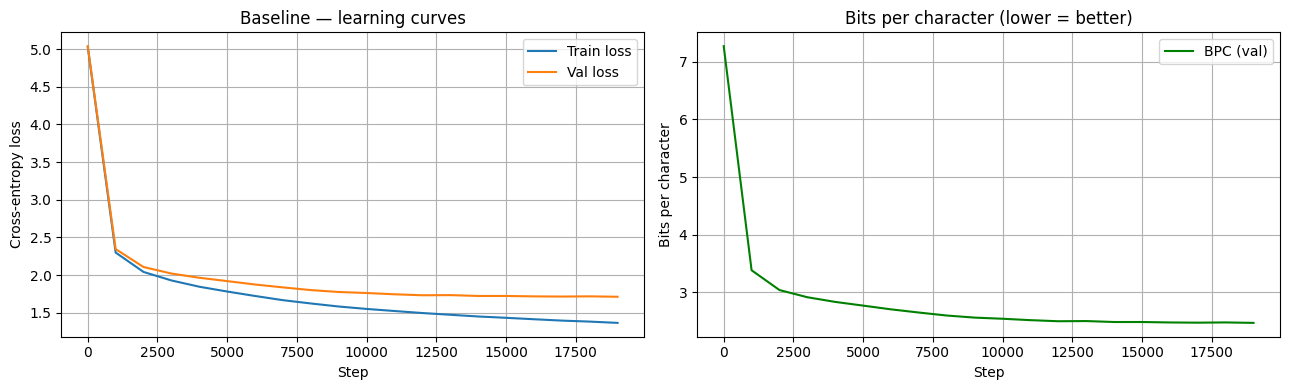

     step  train_loss  val_loss       bpc
15  15000    1.433543  1.723383  2.486316
16  16000    1.414546  1.717946  2.478472
17  17000    1.396433  1.715430  2.474842
18  18000    1.383240  1.718364  2.479075
19  19000    1.366139  1.712833  2.471096


In [13]:
steps = list(range(0, max_iters, eval_interval))

df_base = pd.DataFrame({
    'step': steps,
    'train_loss': train_losses,
    'val_loss': val_losses,
    'bpc': bpc_values
})
df_base.to_csv('training_log_baseline.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(steps, train_losses, label='Train loss')
axes[0].plot(steps, val_losses, label='Val loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Baseline — learning curves')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(steps, bpc_values, color='green', label='BPC (val)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Bits per character')
axes[1].set_title('Bits per character (lower = better)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('learning_curves_baseline.png', dpi=150)
plt.show()
print(df_base.tail())

## 12. Hyperparameter experiments (Stage III)

We vary two parameters against the baseline (4 layers, ctx=256, 20k steps):
- **Exp 1:** n_layer = 2 (shallower model, less capacity)
- **Exp 2:** block_size = 128 (shorter context window)

All other settings identical, same number of steps for a fair comparison.

In [14]:
def run_experiment(exp_name, vocab_size, n_embd, n_head, n_layer,
                   block_size, dropout, lr, max_iters, eval_interval=1000):
    """Train a fresh model with the given config and return loss history."""

    # Rebuild data loader closure with this experiment's block_size
    def get_batch_exp(split):
        source = train_data if split == 'train' else val_data
        ix = torch.randint(len(source) - block_size, (batch_size,))
        x = torch.stack([source[i : i + block_size]         for i in ix])
        y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])
        return x.to(device), y.to(device)

    m = GPTPoetry(vocab_size=vocab_size, n_embd=n_embd, n_head=n_head,
                  n_layer=n_layer, block_size=block_size,
                  dropout=dropout).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)

    @torch.no_grad()
    def est_loss():
        m.eval()
        out = {}
        for split in ['train', 'val']:
            ls = torch.zeros(200)
            for k in range(200):
                X, Y = get_batch_exp(split)
                _, loss = m(X, Y)
                ls[k] = loss.item()
            out[split] = ls.mean()
        m.train()
        return out

    t_losses, v_losses, bpcs = [], [], []
    for step in range(max_iters):
        xb, yb = get_batch_exp('train')
        _, loss = m(xb, yb)
        opt.zero_grad(); loss.backward(); opt.step()

        if step % eval_interval == 0:
            ls = est_loss()
            bpc = ls['val'].item() / math.log(2)
            t_losses.append(ls['train'].item())
            v_losses.append(ls['val'].item())
            bpcs.append(bpc)
            print(f'[{exp_name}] step {step:5d} | train {ls["train"]:.4f} | val {ls["val"]:.4f} | BPC {bpc:.4f}')

    print(f'[{exp_name}] done. Final val loss: {v_losses[-1]:.4f}')
    return t_losses, v_losses, bpcs

print('run_experiment() ready.')

run_experiment() ready.


In [15]:
# Experiment 1: shallower model (2 layers instead of 4)
EXP_ITERS = 20000

tl_exp1, vl_exp1, bpc_exp1 = run_experiment(
    exp_name   = 'Exp1_2layers',
    vocab_size = vocab_size,
    n_embd     = n_embd,
    n_head     = n_head,
    n_layer    = 2,          # <-- changed
    block_size = block_size,
    dropout    = dropout,
    lr         = learning_rate,
    max_iters  = EXP_ITERS
)

[Exp1_2layers] step     0 | train 5.0323 | val 5.0626 | BPC 7.3038
[Exp1_2layers] step  1000 | train 2.3883 | val 2.4249 | BPC 3.4984
[Exp1_2layers] step  2000 | train 2.1537 | val 2.2138 | BPC 3.1939
[Exp1_2layers] step  3000 | train 2.0271 | val 2.1015 | BPC 3.0318
[Exp1_2layers] step  4000 | train 1.9597 | val 2.0542 | BPC 2.9637
[Exp1_2layers] step  5000 | train 1.9136 | val 2.0200 | BPC 2.9143
[Exp1_2layers] step  6000 | train 1.8738 | val 1.9901 | BPC 2.8711
[Exp1_2layers] step  7000 | train 1.8452 | val 1.9688 | BPC 2.8403
[Exp1_2layers] step  8000 | train 1.8190 | val 1.9545 | BPC 2.8198
[Exp1_2layers] step  9000 | train 1.7930 | val 1.9339 | BPC 2.7900
[Exp1_2layers] step 10000 | train 1.7746 | val 1.9219 | BPC 2.7727
[Exp1_2layers] step 11000 | train 1.7553 | val 1.9112 | BPC 2.7573
[Exp1_2layers] step 12000 | train 1.7367 | val 1.8989 | BPC 2.7396
[Exp1_2layers] step 13000 | train 1.7207 | val 1.8886 | BPC 2.7247
[Exp1_2layers] step 14000 | train 1.7090 | val 1.8848 | BPC 2.

In [16]:
# Experiment 2: shorter context window (128 instead of 256)
tl_exp2, vl_exp2, bpc_exp2 = run_experiment(
    exp_name   = 'Exp2_ctx128',
    vocab_size = vocab_size,
    n_embd     = n_embd,
    n_head     = n_head,
    n_layer    = n_layer,
    block_size = 128,        # <-- changed
    dropout    = dropout,
    lr         = learning_rate,
    max_iters  = EXP_ITERS
)

[Exp2_ctx128] step     0 | train 5.0776 | val 5.0809 | BPC 7.3302
[Exp2_ctx128] step  1000 | train 2.1448 | val 2.1999 | BPC 3.1737
[Exp2_ctx128] step  2000 | train 1.9730 | val 2.0607 | BPC 2.9730
[Exp2_ctx128] step  3000 | train 1.8830 | val 1.9931 | BPC 2.8754
[Exp2_ctx128] step  4000 | train 1.8086 | val 1.9450 | BPC 2.8060
[Exp2_ctx128] step  5000 | train 1.7598 | val 1.9102 | BPC 2.7559
[Exp2_ctx128] step  6000 | train 1.7172 | val 1.8811 | BPC 2.7139
[Exp2_ctx128] step  7000 | train 1.6745 | val 1.8491 | BPC 2.6677
[Exp2_ctx128] step  8000 | train 1.6402 | val 1.8376 | BPC 2.6511
[Exp2_ctx128] step  9000 | train 1.6115 | val 1.8231 | BPC 2.6302
[Exp2_ctx128] step 10000 | train 1.5790 | val 1.8082 | BPC 2.6087
[Exp2_ctx128] step 11000 | train 1.5537 | val 1.7911 | BPC 2.5840
[Exp2_ctx128] step 12000 | train 1.5353 | val 1.7827 | BPC 2.5719
[Exp2_ctx128] step 13000 | train 1.5113 | val 1.7840 | BPC 2.5737
[Exp2_ctx128] step 14000 | train 1.4951 | val 1.7719 | BPC 2.5564
[Exp2_ctx1

FINAL VAL LOSS COMPARISON
  Baseline  (4L, ctx=256, 20k): 1.7128  BPC 2.4711
  Exp 1     (2L, ctx=256, 20k): 1.8574  BPC 2.6796
  Exp 2     (4L, ctx=128, 20k): 1.7470  BPC 2.5203


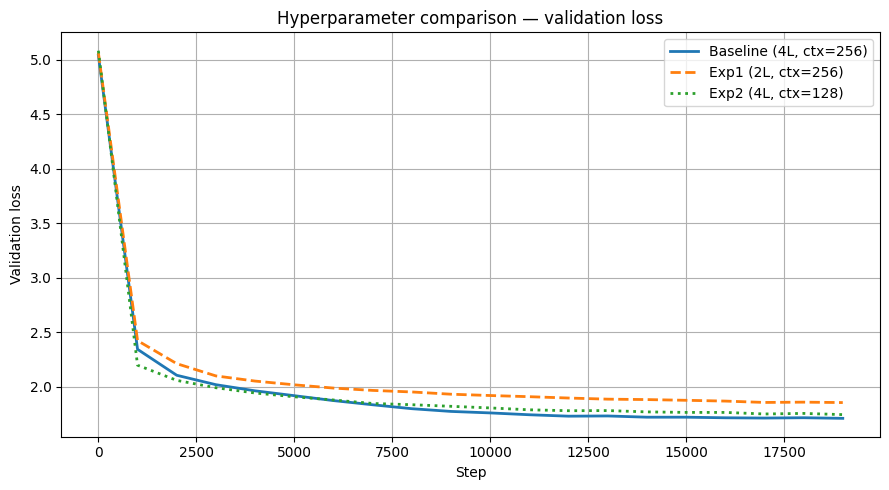

In [17]:
# ── Comparison summary ────────────────────────────────────────────────────
exp_steps = list(range(0, EXP_ITERS, 1000))

print('='*60)
print('FINAL VAL LOSS COMPARISON')
print(f'  Baseline  (4L, ctx=256, 20k): {val_losses[-1]:.4f}  BPC {bpc_values[-1]:.4f}')
print(f'  Exp 1     (2L, ctx=256, 20k): {vl_exp1[-1]:.4f}  BPC {bpc_exp1[-1]:.4f}')
print(f'  Exp 2     (4L, ctx=128, 20k): {vl_exp2[-1]:.4f}  BPC {bpc_exp2[-1]:.4f}')
print('='*60)

plt.figure(figsize=(9, 5))
plt.plot(steps,     val_losses, label='Baseline (4L, ctx=256)', lw=2)
plt.plot(exp_steps, vl_exp1,    label='Exp1 (2L, ctx=256)',     lw=2, linestyle='--')
plt.plot(exp_steps, vl_exp2,    label='Exp2 (4L, ctx=128)',     lw=2, linestyle=':')
plt.xlabel('Step')
plt.ylabel('Validation loss')
plt.title('Hyperparameter comparison — validation loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hyperparameter_comparison.png', dpi=150)
plt.show()

### Interpretation

**Exp 1 (2 layers):** A shallower model has fewer parameters and less representational capacity. Each Transformer block can learn one level of abstraction; with only 2 blocks, the model struggles to compose character n-grams into syllables and then into words. We expect a higher final loss than the baseline.

**Exp 2 (ctx=128):** A shorter context window means the model cannot attend beyond 128 characters. In Мағжан's verse, a typical 4-line stanza spans roughly 160–200 characters. With ctx=128, the model cannot see a full stanza, which prevents it from learning rhyme patterns that span full quatrains. We expect worse structural regularity in generated text even if raw loss is similar.

## 13. Poetry generation (Stage IV)

In [18]:
# Reload baseline model checkpoint
ckpt = torch.load('gpt_poetry_baseline_20k.pt', map_location=device)
cfg  = ckpt['config']
model = GPTPoetry(**cfg).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Baseline model loaded. Val loss at save:', ckpt['val_loss'])

Baseline model loaded. Val loss at save: 1.7128329277038574


In [19]:
PROMPT = 'Желсіз түнде жарық ай\n'

ctx = torch.tensor([encode(PROMPT)], dtype=torch.long, device=device)

print('=== Temperature 0.6 (more deterministic) ===')
g = model.generate(ctx, max_new_tokens=500, temperature=0.6)
gen_t06 = decode(g[0].tolist())
print(gen_t06)

print('\n=== Temperature 0.9 (more creative) ===')
g = model.generate(ctx, max_new_tokens=500, temperature=0.9)
gen_t09 = decode(g[0].tolist())
print(gen_t09)

print('\n=== Top-k=5, temperature=0.8 ===')
g = model.generate(ctx, max_new_tokens=500, temperature=0.8, top_k=5)
gen_topk = decode(g[0].tolist())
print(gen_topk)

# Use the temperature=0.8 version for structural analysis
generated_text = gen_t09

=== Temperature 0.6 (more deterministic) ===
Желсіз түнде жарық ай


Ұлы да жамылған жоқ ойнап.
Жас келін тапса есіп,


Жарықты көрген жас келеді.
Айдар жарық бала жаным,
Есікте айға қара жаным,
Жас құладым да жерден шықпай 
Кірген жаным да күледі.
Есіме алмай жүректің,
Сондықтан жаным да алмай жүрмей ме?!
Күлкі оны – от, өзіме өзіме ме?
Алыстан қалың достар болған арман да
Маған бір маған да оның да өзім де.
Қайда қалмай ма екен берсең де, білмеймін,
Қайда қайда арман қылсам да өзім де.
Аманда алдымда бір саған қылсам да жан,
Күн батыр елім тағдырды қанатын да

=== Temperature 0.9 (more creative) ===
Желсіз түнде жарық ай
Отырып жатыр тұрды қызар.
Оның молдағы қадам қысыңа,
Білмейді асау жас та алып қыр,
Тағдырдың тайын-тазаң асқары.
Біле алмай ма екен бұғып шығып,
Суықтан күйге «кел, жүрегім толыттық шығып,
Қаңқ етпес ағарып құлды шыдықтың, сырлатты,
Сөйлетіп жасыңды Адамылып күліп,
Күңіреніп тотықтан адамылып тұр бір тұр.
Алыстанды жеңгер басып, күргенде айтпады
Алып көрініп, көтері

## 14. Structural analysis of generated poetry

Corpus    — avg line length: 27.0 chars
Generated — avg line length: 33.9 chars


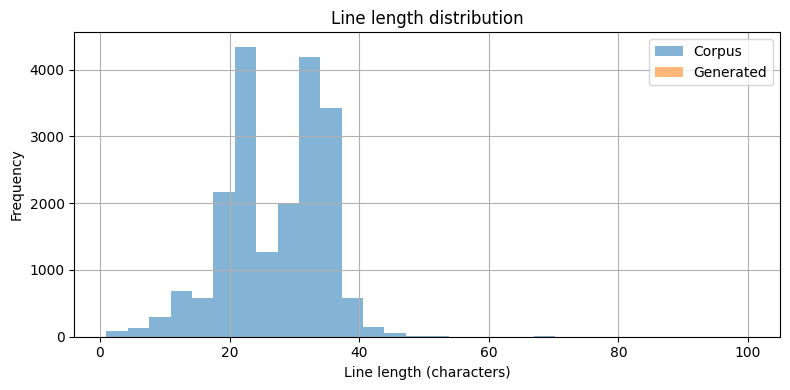

In [20]:
# ── Line length distribution ──────────────────────────────────────────────
def get_line_lengths(txt):
    return [len(l.strip()) for l in txt.split('\n') if l.strip()]

corpus_lengths    = get_line_lengths(text)
generated_lengths = get_line_lengths(generated_text)

print(f'Corpus    — avg line length: {sum(corpus_lengths)/len(corpus_lengths):.1f} chars')
print(f'Generated — avg line length: {sum(generated_lengths)/len(generated_lengths):.1f} chars')

plt.figure(figsize=(8, 4))
plt.hist(corpus_lengths,    bins=30, alpha=0.55, label='Corpus')
plt.hist(generated_lengths, bins=30, alpha=0.55, label='Generated')
plt.xlabel('Line length (characters)')
plt.ylabel('Frequency')
plt.title('Line length distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('line_lengths.png', dpi=150)
plt.show()

In [21]:
# ── Stanza length distribution ────────────────────────────────────────────
def stanza_lengths(txt):
    stanzas = [s for s in txt.split('\n\n') if s.strip()]
    return [len([l for l in s.split('\n') if l.strip()]) for s in stanzas]

c_stanzas = stanza_lengths(text)
g_stanzas = stanza_lengths(generated_text)

print(f'Corpus    — avg stanza length: {sum(c_stanzas)/len(c_stanzas):.2f} lines')
print(f'Generated — avg stanza length: {sum(g_stanzas)/len(g_stanzas):.2f} lines')

from collections import Counter
print('\nCorpus stanza length distribution:', dict(Counter(c_stanzas).most_common(6)))
print('Generated stanza length distribution:', dict(Counter(g_stanzas).most_common(6)))

Corpus    — avg stanza length: 13.96 lines
Generated — avg stanza length: 15.00 lines

Corpus stanza length distribution: {3: 705, 1: 215, 2: 84, 4: 69, 26: 42, 30: 25}
Generated stanza length distribution: {15: 1}


Corpus    — avg syllables/line: 9.07
Generated — avg syllables/line: 11.20

Note: Kazakh classical verse (Мағжан) typically uses 7–11 syllable lines.
If the generated average is in this range, the model has learnt rhythmic constraints.


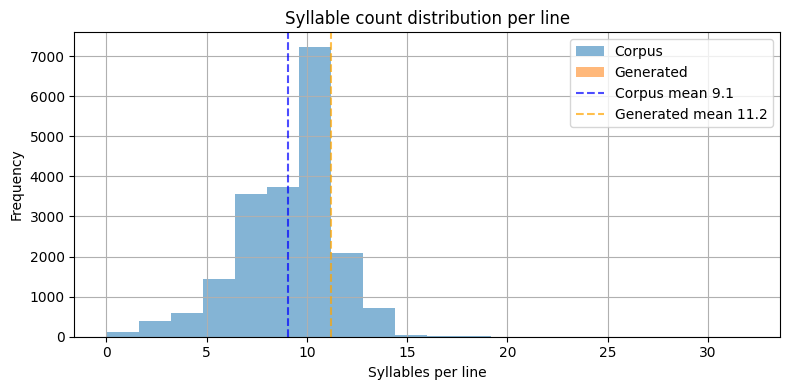

In [22]:
# ── Syllable count per line (Kazakh vowel counting) ───────────────────────
KAZAKH_VOWELS = set('аәеёиіоөуүыэюяАӘЕЁИІОӨУҮЫЭЮЯ')

def count_syllables(word):
    return sum(1 for ch in word if ch in KAZAKH_VOWELS)

def syllables_per_line(txt):
    lines = [l.strip() for l in txt.split('\n') if l.strip()]
    return [sum(count_syllables(w) for w in l.split()) for l in lines]

corpus_syl    = syllables_per_line(text)
generated_syl = syllables_per_line(generated_text)

avg_c = sum(corpus_syl) / len(corpus_syl)
avg_g = sum(generated_syl) / len(generated_syl)

print(f'Corpus    — avg syllables/line: {avg_c:.2f}')
print(f'Generated — avg syllables/line: {avg_g:.2f}')
print()
print('Note: Kazakh classical verse (Мағжан) typically uses 7–11 syllable lines.')
print('If the generated average is in this range, the model has learnt rhythmic constraints.')

plt.figure(figsize=(8, 4))
plt.hist(corpus_syl,    bins=20, alpha=0.55, label='Corpus')
plt.hist(generated_syl, bins=20, alpha=0.55, label='Generated')
plt.xlabel('Syllables per line')
plt.ylabel('Frequency')
plt.title('Syllable count distribution per line')
plt.axvline(avg_c, color='blue',  linestyle='--', alpha=0.7, label=f'Corpus mean {avg_c:.1f}')
plt.axvline(avg_g, color='orange',linestyle='--', alpha=0.7, label=f'Generated mean {avg_g:.1f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('syllable_distribution.png', dpi=150)
plt.show()

In [23]:
# ── Rhyme analysis — last word endings ───────────────────────────────────
import re

STRIP_PUNCT = str.maketrans('', '', '.,!?;:—-–«»\"()')

def line_endings(txt, n=4):
    lines = [l.strip() for l in txt.split('\n') if l.strip()]
    endings = []
    for line in lines:
        words = line.split()
        if not words:
            continue
        last_word = words[-1].translate(STRIP_PUNCT)
        if len(last_word) >= n:
            endings.append(last_word[-n:])
    return Counter(endings)

c_end = line_endings(text, n=4)
g_end = line_endings(generated_text, n=4)

print('Most common line endings in corpus (last 4 chars):')
print(c_end.most_common(10))

print('\nMost common line endings in generated text (last 4 chars):')
print(g_end.most_common(10))

# Overlap: how many of the top-20 corpus endings appear in top-20 generated?
top_c = set(e for e, _ in c_end.most_common(20))
top_g = set(e for e, _ in g_end.most_common(20))
overlap = top_c & top_g
print(f'\nOverlap between top-20 corpus and generated endings: {len(overlap)}/20')
print('Shared endings:', overlap)

Most common line endings in corpus (last 4 chars):
[('аған', 251), ('айды', 171), ('анда', 154), ('екен', 154), ('алып', 124), ('алды', 120), ('айын', 118), ('лған', 113), ('ында', 113), ('амын', 109)]

Most common line endings in generated text (last 4 chars):
[('ығып', 2), ('ызар', 1), ('сыңа', 1), ('қары', 1), ('атты', 1), ('үліп', 1), ('пады', 1), ('арып', 1), ('ұрса', 1), ('ндай', 1)]

Overlap between top-20 corpus and generated endings: 1/20
Shared endings: {'ндай'}


In [24]:
# ── Final summary table ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'metric': [
        'avg line length (chars)',
        'avg stanza length (lines)',
        'avg syllables per line',
        'top-20 ending overlap'
    ],
    'corpus': [
        f"{sum(corpus_lengths)/len(corpus_lengths):.1f}",
        f"{sum(c_stanzas)/len(c_stanzas):.2f}",
        f"{sum(corpus_syl)/len(corpus_syl):.2f}",
        '—'
    ],
    'generated': [
        f"{sum(generated_lengths)/len(generated_lengths):.1f}",
        f"{sum(g_stanzas)/len(g_stanzas):.2f}",
        f"{sum(generated_syl)/len(generated_syl):.2f}",
        f"{len(overlap)}/20"
    ]
})
print(summary.to_string(index=False))

                   metric corpus generated
  avg line length (chars)   27.0      33.9
avg stanza length (lines)  13.96     15.00
   avg syllables per line   9.07     11.20
    top-20 ending overlap      —      1/20
